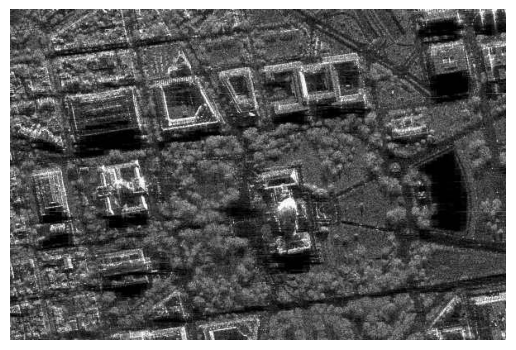

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(r'C:\Users\egoru\course-image-processing-2026\lab1\sar_1_gray.jpg')

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

C:\Users\egoru\AppData\Local\Temp\ipykernel_29140\4173506733.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(), 256, [0, 256], color='gray')


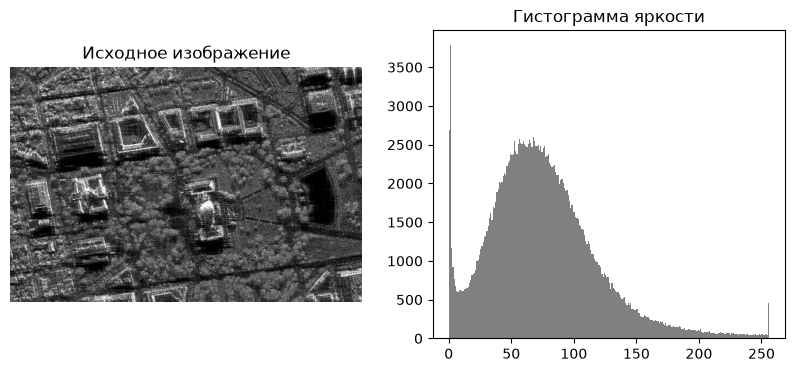

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r'C:\Users\egoru\course-image-processing-2026\lab1\sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(img.ravel(), 256, [0, 256], color='gray')
plt.title('Гистограмма яркости')

plt.show()

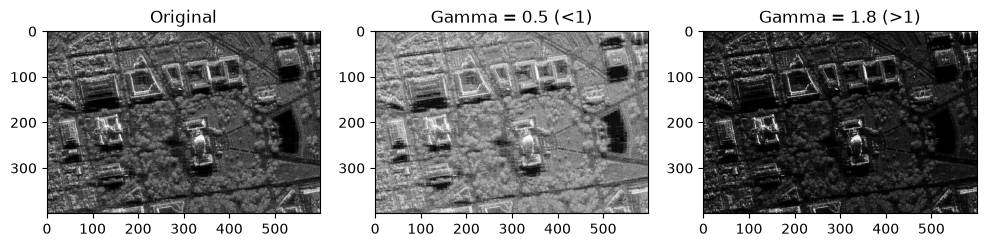

In [4]:
import numpy as np

def apply_gamma(image, gamma):
    inv_gamma = gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

img_gamma_low = apply_gamma(img, gamma=0.5)
img_gamma_high = apply_gamma(img, gamma=1.8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
plt.subplot(1, 3, 2); plt.imshow(img_gamma_low, cmap='gray'); plt.title('Gamma = 0.5 (<1)')
plt.subplot(1, 3, 3); plt.imshow(img_gamma_high, cmap='gray'); plt.title('Gamma = 1.8 (>1)')
plt.show()

In [5]:
from skimage.metrics import structural_similarity as ssim

def calculate_metrics(original, processed):
    mse_val = np.mean((original.astype("float") - processed.astype("float")) ** 2)
    ssim_val = ssim(original, processed)
    return mse_val, ssim_val

mse_low, ssim_low = calculate_metrics(img, img_gamma_low)
mse_high, ssim_high = calculate_metrics(img, img_gamma_high)

print(f"Сравнение с Gamma = 0.5: MSE = {mse_low:.2f}, SSIM = {ssim_low:.4f}")
print(f"Сравнение с Gamma = 1.8: MSE = {mse_high:.2f}, SSIM = {ssim_high:.4f}")

Сравнение с Gamma = 0.5: MSE = 3250.43, SSIM = 0.7875
Сравнение с Gamma = 1.8: MSE = 1837.90, SSIM = 0.6316


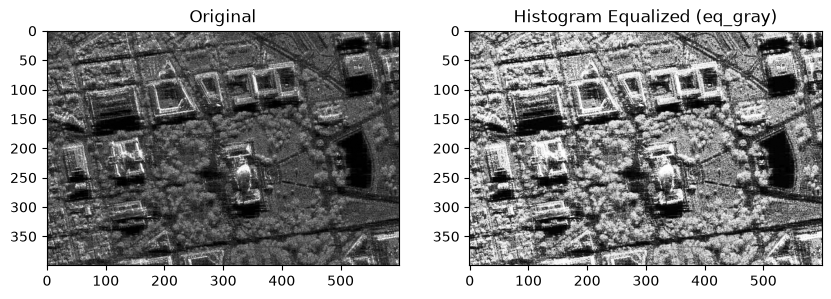

Результат Equalization: MSE = 4021.80, SSIM = 0.6991


In [6]:
img_eq = cv2.equalizeHist(img)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
plt.subplot(1, 2, 2); plt.imshow(img_eq, cmap='gray'); plt.title('Histogram Equalized (eq_gray)')
plt.show()

mse_eq, ssim_eq = calculate_metrics(img, img_eq)
print(f"Результат Equalization: MSE = {mse_eq:.2f}, SSIM = {ssim_eq:.4f}")

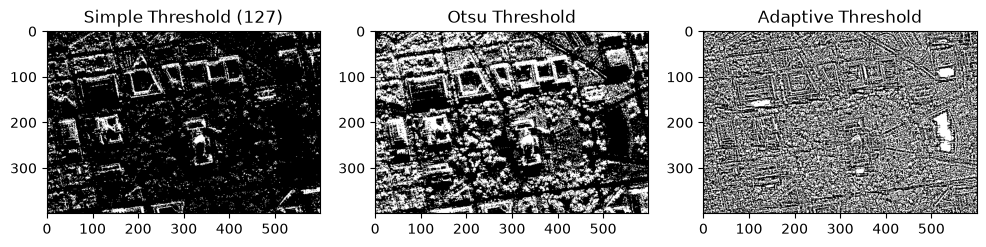

In [7]:
_, thresh_simple = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

_, thresh_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

thresh_adapt = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(thresh_simple, cmap='gray'); plt.title('Simple Threshold (127)')
plt.subplot(1, 3, 2); plt.imshow(thresh_otsu, cmap='gray'); plt.title('Otsu Threshold')
plt.subplot(1, 3, 3); plt.imshow(thresh_adapt, cmap='gray'); plt.title('Adaptive Threshold')
plt.show()